**REQUIREMENTS**

This is an python libary that allows easy API calls to the Meteostat. Meteostat is an open source project that stores historic weather data. This library will be used for obtaining weather data as explained in the proposal.

---

In [ ]:
%pip install meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 17.0 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requi

**EDA Phase**

These datasets contain different .csv files so the first goal is to understand what each of the .csv files contain. To understand it, some of the relevant .csv files are selected and first 5 - 20 rows are selected.

---



In [ ]:
import pandas as pd
import numpy as np
import meteostat as ms
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from datetime import datetime


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
result_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/results.csv')
races_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/races.csv')
pitstop_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/pit_stops.csv')
circuit_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/circuits.csv')
lap_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/lap_times.csv')


In [ ]:
result_data.head(20)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.18,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.1,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


**Result Dataset**

Contains information of driver’s performance in each race according to starting, finishing position etc.

---

**Non-Essential Columns in Result Dataset:**


1.   positionText and position: The finish order of the racers in an race can be found in positionOrder.
2.   fastestLapSpeed: For some drivers it is not avaliable and it will not be used in this project.
3.   number: It is the number of the driver which is not neccessary since drivers are identified through driverId.
4.   time and milliseconds: It contains the finish times after the winner however it is both not neccessary and contain missing values.
5.   points: The point system changes recently in F1 therefore some races contain old format and some contain the new format.

In this dataset the rank column gives the rank of the driver according to their fastest lap.

---



In [ ]:
races_data.head(5)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1182,2026,14,81,Spanish Grand Prix,2026-09-13,13:00:00,https://en.wikipedia.org/wiki/2026_Spanish_Gra...,2026-09-11,11:30:00,2026-09-11,15:00:00,2026-09-12,10:30:00,2026-09-12,14:00:00,\N,\N
1,1188,2026,20,80,Las Vegas Grand Prix,2026-11-22,4:00:00,https://en.wikipedia.org/wiki/2026_Las_Vegas_G...,2026-11-20,0:30:00,2026-11-20,4:00:00,2026-11-21,0:30:00,2026-11-21,4:00:00,\N,\N
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,https://en.wikipedia.org/wiki/2025_Las_Vegas_G...,2025-11-21,0:30:00,2025-11-21,4:00:00,2025-11-22,0:30:00,2025-11-22,4:00:00,\N,\N
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,https://en.wikipedia.org/wiki/2024_Las_Vegas_G...,2024-11-21,2:30:00,2024-11-21,6:00:00,2024-11-22,2:30:00,2024-11-22,6:00:00,\N,\N
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,https://en.wikipedia.org/wiki/2023_Las_Vegas_G...,2023-11-16,4:30:00,2023-11-16,8:00:00,2023-11-17,4:30:00,2023-11-17,8:00:00,\N,\N


**Race Dataset**

Contains information about race date and time.

---

**Non-Essential Columns in Race Dataset**



1.   FP1, FP2 etc. refers to different practice sessions time which is not neccessary since this project will not use those times.
2.   url

---



In [ ]:
pitstop_data.head(5)

,raceId,driverId,stop,lap,time,duration,milliseconds
0,258,100,1,1,14:01:34,49.111,49111
1,258,79,1,17,14:20:46,28.482,28482
2,258,57,1,18,14:22:35,43.745,43745
3,258,71,1,18,14:23:00,21.992,21992
4,258,105,1,19,14:24:39,27.693,27693


**Pit Stop Dataset**

Contains the laps and durations of pitstop of drivers in each race.

---

**Non-Essential Columns in Pitstop Dataset**



1.   time: Since the pit stop lap is known, it is easier to work with therefore this column is not neccessary.

---



In [ ]:
circuit_data.head(5)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Sepang,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


**Circuit Dataset**

Contains data about coordinates and location of the circuits.

---

**Non-Essential Columns in Circuit Dataset**



1.   url

---

In [ ]:
lap_data.head(10)

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342
5,841,20,6,1,1:32.605,92605
6,841,20,7,1,1:32.502,92502
7,841,20,8,1,1:32.537,92537
8,841,20,9,1,1:33.240,93240
9,841,20,10,1,1:32.572,92572


**Lap Data**

This contains information about drivers each race and their lap times in each lap. All columns contain valuable information.

---

In [ ]:
result_data.drop(columns=['number', 'fastestLapSpeed', 'position', 'positionText', 'time', 'milliseconds'], inplace=True)
races_data.drop(columns=['url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time'], inplace=True)
pitstop_data.drop(columns=['time'], inplace=True)
circuit_data.drop(columns=['url'], inplace=True)

**Important Changes**

Since F1 started in 1950 there have been number of regulations and chages to the cars. Therefore, to create an logical model only races after 2010 will be considered.

Also, the race and result data will be merged since they contain valuable information about the each race. Therefore the raceId, driverId and circuitId columns can be used simultaneously for different merges of datasets.

---

In [ ]:
race_result_merge = pd.merge(races_data, result_data, on='raceId', how='inner')
race_result_merge.head(10)

,raceId,year,round,circuitId,name,date,time,resultId,driverId,constructorId,grid,positionOrder,points,laps,fastestLap,rank,fastestLapTime,statusId
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,9,2,1,25.0,50,50,1,1:33.365,1
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,131,4,2,18.0,50,50,9,1:34.592,1
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,131,17,3,15.0,50,48,2,1:33.998,1
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,6,9,4,12.0,50,43,3,1:34.304,1
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,3,3,5,10.0,50,42,4,1:34.496,1
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27189,865,215,8,6,8.0,50,50,10,1:34.620,1
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27190,807,15,11,7,6.0,50,49,8,1:34.592,1
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27191,1,6,19,8,4.0,50,49,6,1:34.553,1
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27192,839,210,13,9,2.0,50,48,7,1:34.557,1
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27193,860,210,14,10,1.0,50,50,5,1:34.519,1


In [ ]:
print(f"Length Before: {len(race_result_merge)}")
race_result_merge = race_result_merge[(race_result_merge['year'] >= 2010) & (race_result_merge['year'] < 2026)]
print(f"Length After: {len(race_result_merge)}")


Length Before: 27284
Length After: 6895


Now this dataset can be used as the main dataset to merge with other datasets. Thus making it easy to get information about each driver for each race.

---

In [ ]:
pitstop_race = pd.merge(race_result_merge, pitstop_data, on=['raceId', 'driverId'], how='inner')
pitstop_race.head(10)

,raceId,year,round,circuitId,name,date,time,resultId,driverId,constructorId,grid,positionOrder,points,laps,fastestLap,rank,fastestLapTime,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,9,2,1,25.0,50,50,1,1:33.365,1,1,25,21.708,21708
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,131,4,2,18.0,50,50,9,1:34.592,1,1,17,20.929,20929
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,131,17,3,15.0,50,48,2,1:33.998,1,1,2,21.968,21968
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,6,9,4,12.0,50,43,3,1:34.304,1,1,24,21.351,21351
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,3,3,5,10.0,50,42,4,1:34.496,1,1,22,21.164,21164
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27189,865,215,8,6,8.0,50,50,10,1:34.620,1,1,20,21.324,21324
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27190,807,15,11,7,6.0,50,49,8,1:34.592,1,1,30,22.333,22333
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27191,1,6,19,8,4.0,50,49,6,1:34.553,1,1,29,21.638,21638
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27192,839,210,13,9,2.0,50,48,7,1:34.557,1,1,27,22.389,22389
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27193,860,210,14,10,1.0,50,50,5,1:34.519,1,1,17,21.491,21491


Check for empty values in the pitstop times.

In [ ]:
print((pitstop_race['milliseconds'] == r'\N').any())

False


In [ ]:
print((pitstop_race['milliseconds'] == '0').any())

False


**Average Pit Stop Duration in each Season**

This graph gives the avg pitstop times and their change throughout the years. From the graph it can be seen that generally before 2020 most of the pit stop times are lower than 5000 milliseconds. However, after 2020 the pitstop times have at least doubled and in year 2021 has significantly higher avg compared to the other years.

---

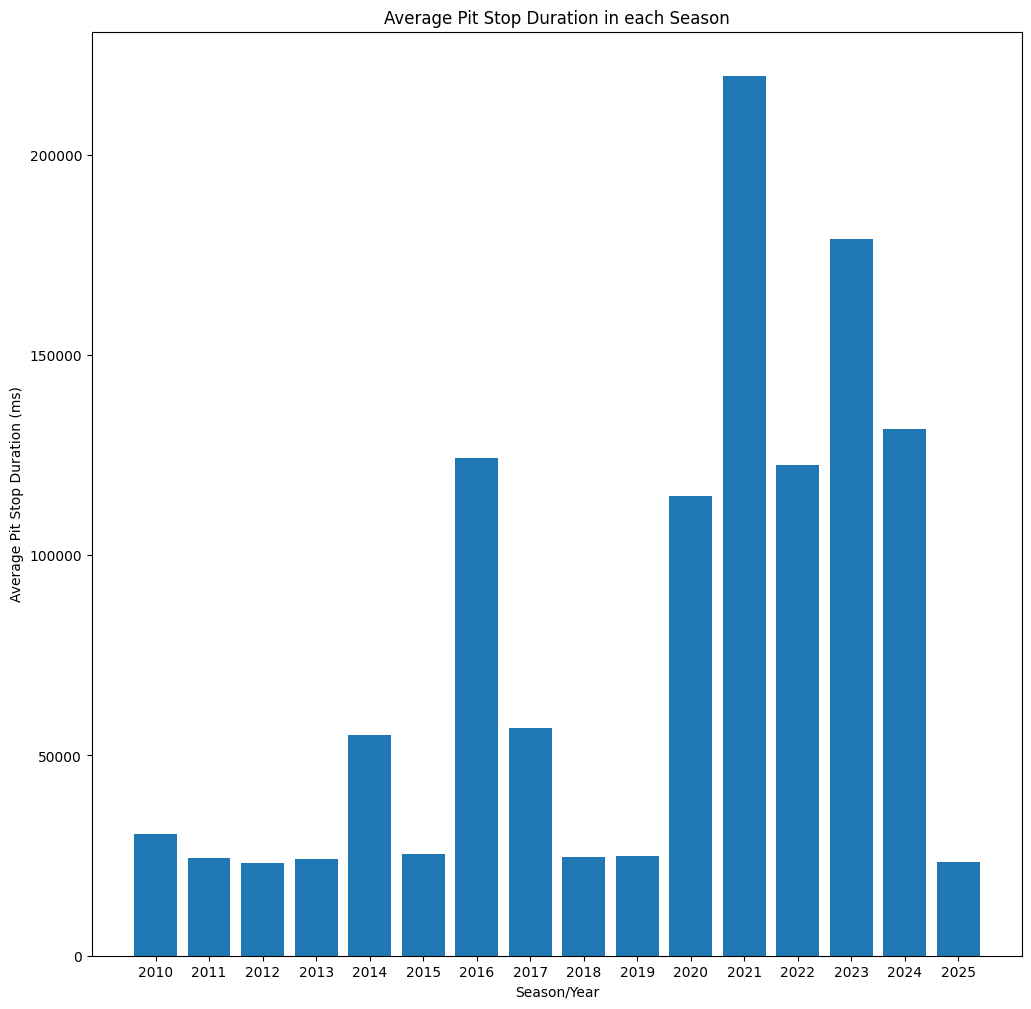

In [ ]:
pitstop_race['milliseconds'] = pd.to_timedelta(pitstop_race['milliseconds'])
avg_pit_stop_times = (pitstop_race.dropna(subset=['year', 'milliseconds']).groupby('year')['milliseconds'].mean().sort_index().reset_index())
fig, ax = plt.subplots(figsize=(12, 12))
ax.bar(avg_pit_stop_times['year'], avg_pit_stop_times['milliseconds'])
ax.set_xticks(avg_pit_stop_times['year'])
ax.set_xlabel('Season/Year')
ax.set_ylabel('Average Pit Stop Duration (ms)')
ax.set_title('Average Pit Stop Duration in each Season')
plt.show()

**First Pit Stop**

In F1 the different tracks can have different number of ideal pit stop counts. However due to the regulations every driver MUST pit at least once in each race. Therefore the first pit stop laps can be analyzed with different features for correlation.

---

In [ ]:
first_pit_stop_subset = pitstop_race[pitstop_race['stop'] == 1]
first_pit_stop_subset['lap'] = first_pit_stop_subset['lap'].astype(int)
avg_pit_stop_each_race = (first_pit_stop_subset.dropna(subset=['name', 'lap']).groupby('name')['lap'].mean().sort_index().reset_index())


**First Pit Stop Graph**

From this graph it can be seen that the first pit stop lap can change significantly for different circuits maximum being lap 30 and min being lap 12. However for most of the circuits racers pit in lap 15 - 20.

---

Text(0, 0.5, 'First Pit Stop Lap')

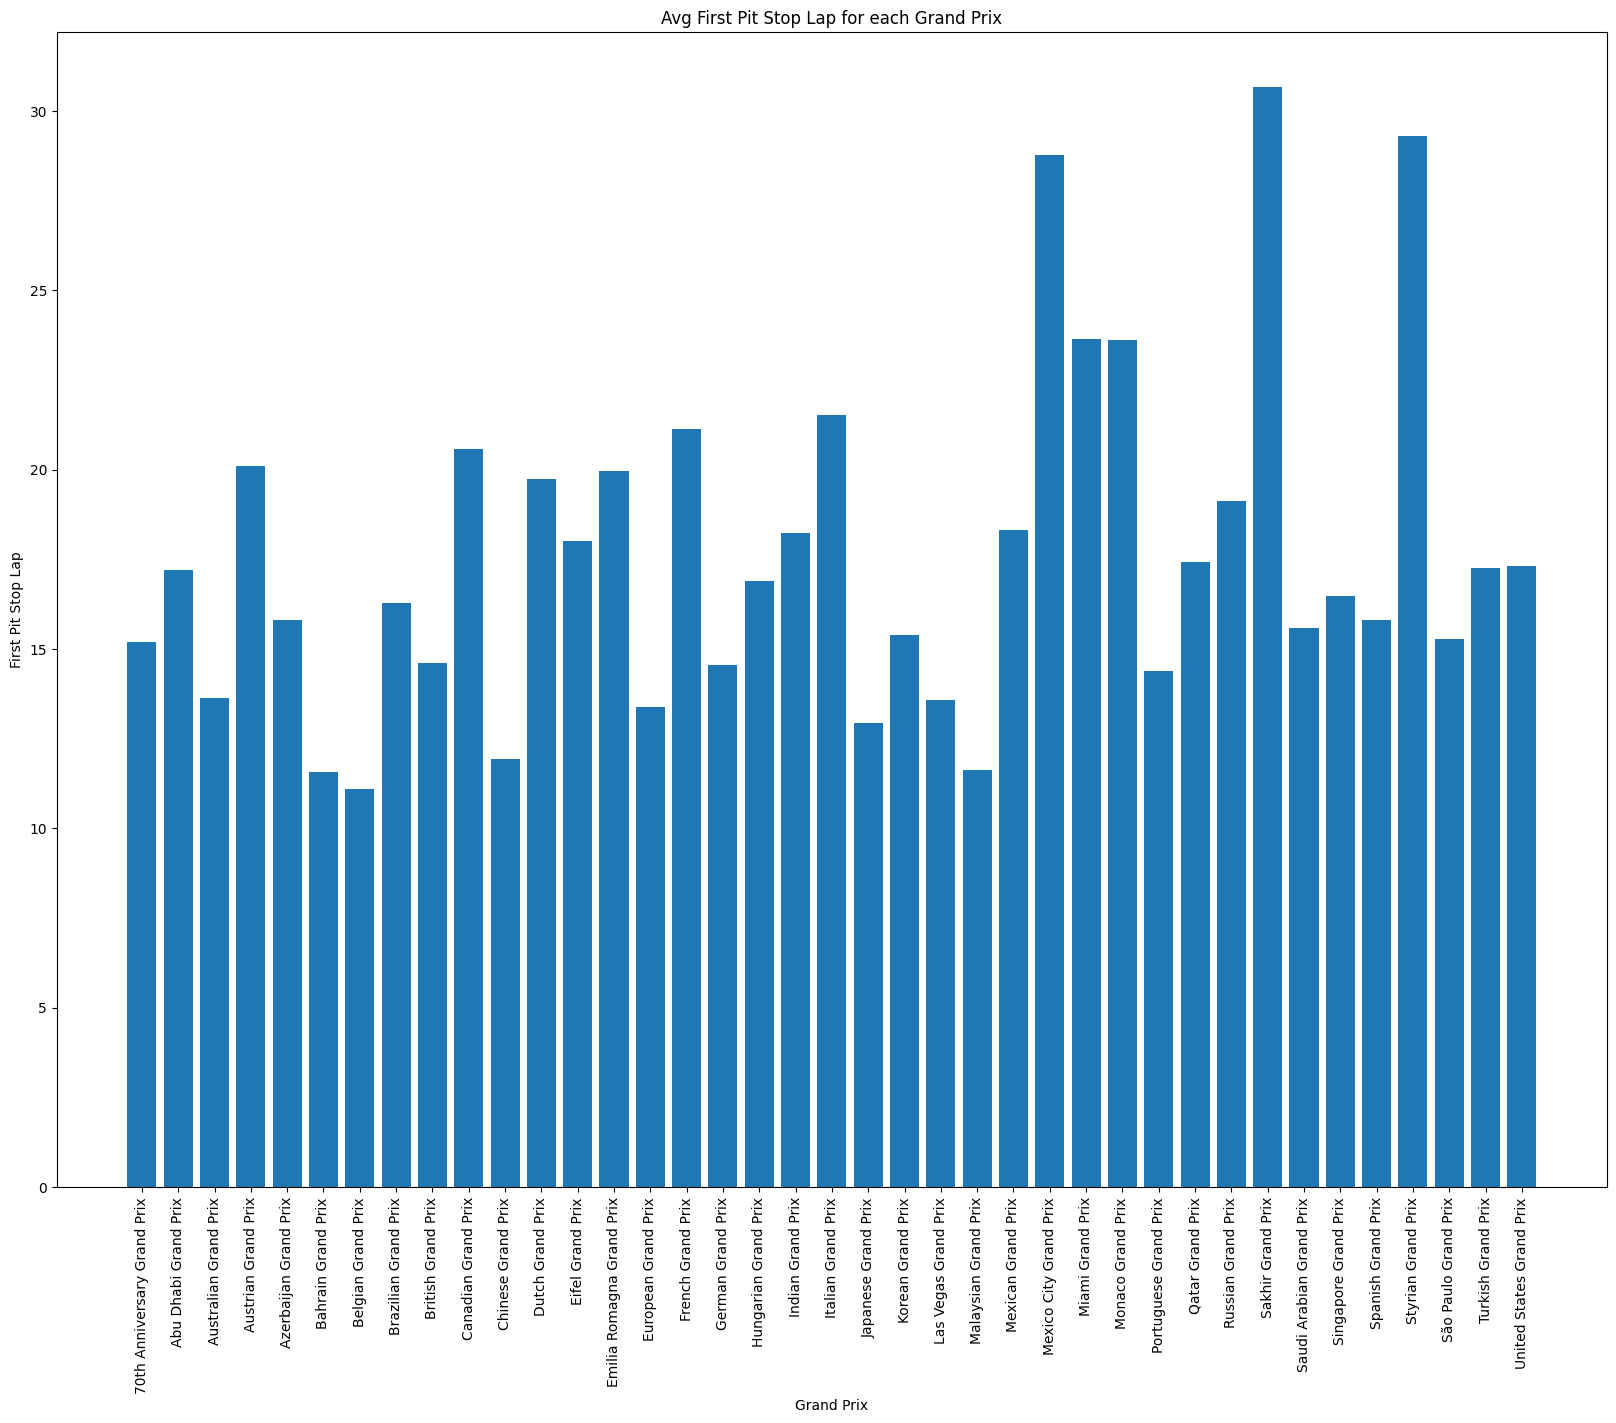

In [ ]:
fig, ax = plt.subplots(figsize=(20, 15))
ax.bar(avg_pit_stop_each_race['name'], avg_pit_stop_each_race['lap'])
ax.tick_params(axis='x', rotation=90)
ax.set_title('Avg First Pit Stop Lap for each Grand Prix')
ax.set_xlabel('Grand Prix')
ax.set_ylabel('First Pit Stop Lap')

**First Pit Stop for Specific Races**

British, Japanese and Monaco are held in the same circuit for a great number of years. Therefore first pit stop laps of these circuits can be used for finding an pattern.

---

In [ ]:
monaco = first_pit_stop_subset.loc[first_pit_stop_subset['name'] == "Monaco Grand Prix"]
monaco = (monaco.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index().reset_index())
monaco

,year,lap
0,2010,19.578947
1,2011,24.434783
2,2012,28.714286
3,2013,24.000000
4,2014,22.842105
5,2015,25.736842
6,2016,15.650000
7,2017,32.894737
8,2018,20.200000
9,2019,24.050000


In [ ]:
jp = first_pit_stop_subset.loc[first_pit_stop_subset['name'] == "Japanese Grand Prix"]
jp = (jp.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index().reset_index())
jp

,year,lap
0,2010,20.500000
1,2011,11.708333
2,2012,13.863636
3,2013,9.950000
4,2014,2.000000
5,2015,11.050000
6,2016,15.454545
7,2017,21.470588
8,2018,20.500000
9,2019,18.157895


In [ ]:
br = first_pit_stop_subset.loc[first_pit_stop_subset['name'] == "British Grand Prix"]
br = (br.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index().reset_index())
br

,year,lap
0,2010,16.782609
1,2011,11.409091
2,2012,13.739130
3,2013,11.500000
4,2014,23.529412
5,2015,18.866667
6,2016,5.818182
7,2017,22.277778
8,2018,20.052632
9,2019,14.105263


**Graph Analysis**

From the graph it can be seen that British GP and Japanese GP sometimes follow a similar trend however Monaco does not follow that trend. This may be due to British and Japanese GP being an track circuit and Monaco being an street circuit.

---

Text(0.5, 1.0, 'Changes in the pistop laps between 2010 and 2026 in Monaco, Japanese and British GP')

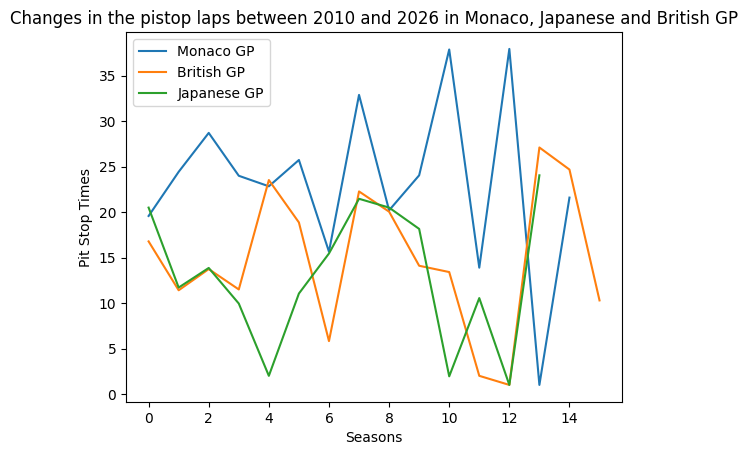

In [ ]:
plt.plot(monaco['lap'], label="Monaco GP")
plt.plot(br['lap'], label = "British GP")
plt.plot(jp['lap'], label = "Japanese GP")
plt.xlabel("Seasons")
plt.legend(loc="upper left")
plt.ylabel("Pit Stop Times")
plt.title("Changes in the pistop laps between 2010 and 2026 in Monaco, Japanese and British GP")

In [ ]:
pitstop_race_final = pitstop_race[pitstop_race['stop'] == 1]
pitstop_race_final

,raceId,year,round,circuitId,name,date,time,resultId,driverId,constructorId,grid,positionOrder,points,laps,fastestLap,rank,fastestLapTime,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,9,2,1,25.0,50,50,1,1:33.365,1,1,25,21.708,0 days 00:00:00.000021708
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,131,4,2,18.0,50,50,9,1:34.592,1,1,17,20.929,0 days 00:00:00.000020929
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,131,17,3,15.0,50,48,2,1:33.998,1,1,2,21.968,0 days 00:00:00.000021968
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,6,9,4,12.0,50,43,3,1:34.304,1,1,24,21.351,0 days 00:00:00.000021351
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,3,3,5,10.0,50,42,4,1:34.496,1,1,22,21.164,0 days 00:00:00.000021164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12711,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20360,812,164,22,14,0.0,53,48,16,1:35.045,15,1,8,27.526,0 days 00:00:00.000027526
12713,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20361,10,166,23,15,0.0,41,37,15,1:34.230,22,1,9,28.501,0 days 00:00:00.000028501
12714,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20362,810,166,24,16,0.0,26,17,17,1:36.607,9,1,10,27.693,0 days 00:00:00.000027693
12716,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20363,20,9,1,17,0.0,25,22,13,1:31.556,36,1,9,24.527,0 days 00:00:00.000024527


**Data Creation for Hypothesi Test 1**

---

In [ ]:
pitstop_race_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test1.csv')


**Track Table**

This table is created to have information about tracks in an single table.

---

In [ ]:
race_location = pd.merge(races_data, circuit_data, on=['circuitId'], how='inner')
race_location = race_location[(race_location['year'] >= 2010) & (race_location['year'] < 2026)]
race_location.drop(columns=['name_y'], inplace=True)
race_location.head(5)


,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642
6,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0
7,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0


**Temprature Data**

In this part the temprature data for each grand prix is collected by using the previous table. In the previous table the date and coordinates of the tracks are available therefore by using them it sends requests to Meteostat for weather information. (The print of numbers is only used for checking if it works correctly)

---

In [ ]:
race_location['temp'] = np.nan

for index, row in race_location.iterrows():
  date = row['date'].split('-')
  new_month = date[1]
  if(date[1][0] == '0'):
    new_month = date[1][1]
  date[1] = new_month

  time = row['time'].split(':')
  start = datetime(int(date[0]), int(date[1]), int(date[2]))
  end = start
  POINT = ms.Point(float(row['lat']), float(row['lng']))
  stations = ms.stations.nearby(POINT, radius=200000, limit=4)
  ts = ms.daily(station=stations, start=start, end=end)
  df = ts.fetch()
  if(df is not None):
    if('temp' in df.columns):
      race_location.loc[index, 'temp'] = df['temp'].iloc[0]
    elif('tmin' in df.columns and 'tmax' in df.columns):
      race_location.loc[index, 'temp'] = (df['tmax'].iloc[0] + df['tmin'].iloc[0])/2
race_location.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2
6,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9
7,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4
8,1102,2023,5,79,Miami Grand Prix,2023-05-07,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.1
9,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,27.7
11,1167,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,21.6
12,1143,2024,23,78,Qatar Grand Prix,2024-12-01,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,20.8
13,1115,2023,17,78,Qatar Grand Prix,2023-10-08,17:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,33.4


**Analysis of Results**

This part is used for checking how many races have the weather so that only those could be used in analysis. From the graph it can be seen that it found weather data for the huge majority of the races.

---

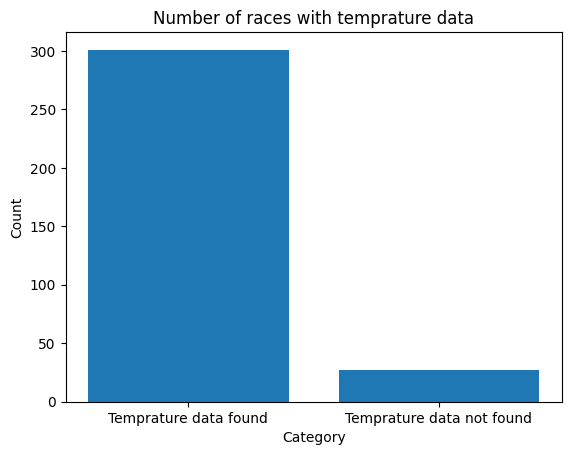

In [ ]:
invalid_data = race_location['temp'].isnull().sum()
valid_data = len(race_location) - invalid_data


legend = ['Temprature data found', 'Temprature data not found']
vals = [valid_data, invalid_data]

plt.bar(legend, vals)
plt.title("Number of races with temprature data")
plt.xlabel("Category")
plt.ylabel('Count')
plt.show()

**Analysis of Results 2**

This graph is used for whether the missing data comes from the same races or for a specific season. The graph shows that the majority comes from British GP and Russian GP.

---

Text(0, 0.5, 'Grand Prix')

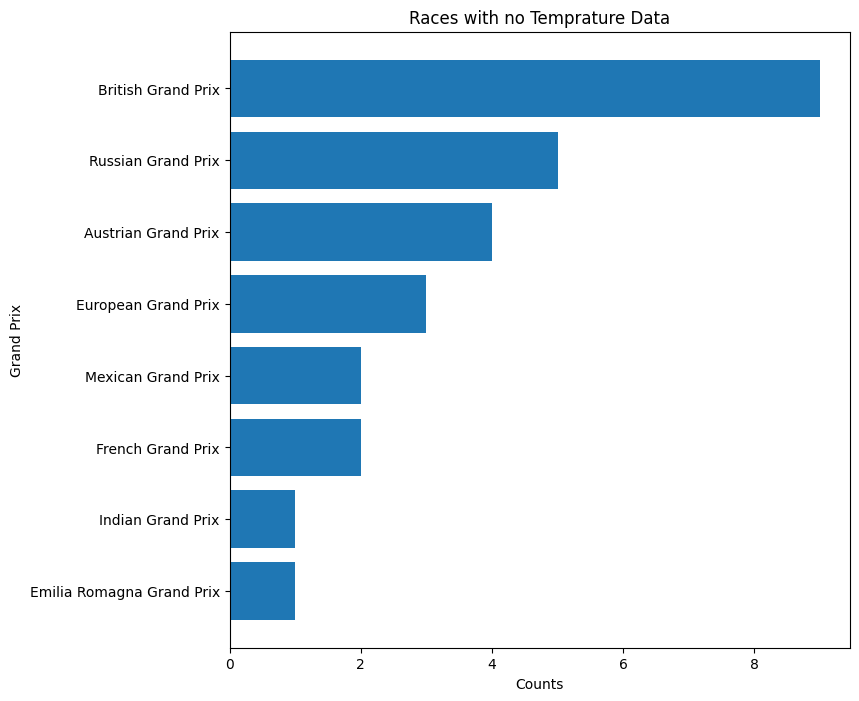

In [ ]:
invalid_races = race_location[['name_x', 'temp']]
invalid_races = invalid_races[invalid_races['temp'].isnull()]
invalid_races = invalid_races.groupby('name_x')['temp'].size().sort_values().reset_index()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(invalid_races['name_x'], invalid_races['temp'])
ax.set_title('Races with no Temprature Data')
ax.set_xlabel('Counts')
ax.set_ylabel('Grand Prix')


In [ ]:
print(f"Count of Total Races after 2010: {len(race_location)}")
race_location_temp = race_location[race_location['temp'].notna()]
print(f"Races with valid temprature data after 2010: {len(race_location_temp)} ")

Count of Total Races after 2010: 328
Races with valid temprature data after 2010: 301 


**Create the Table for the Hypothesis Test 2**

---

In [ ]:
stop_count = pitstop_data.groupby(['raceId'])['stop'].mean().reset_index()
stop_count

,raceId,stop
0,1,1.666667
1,2,2.000000
2,3,1.483871
3,4,1.571429
4,5,1.718750
...,...,...
595,1167,1.609756
596,1168,1.259259
597,1169,1.531250
598,1170,1.105263


In [ ]:
hyp2_final = pd.merge(stop_count, race_location_temp, on=['raceId'], how='inner')
hyp2_final['stop_rank'] = hyp2_final['stop'].rank()
hyp2_final['temp_rank'] = hyp2_final['temp'].rank()
hyp2_final

,raceId,stop,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop_rank,temp_rank
0,337,1.095238,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,bahrain,Sakhir,Bahrain,26.03250,50.51060,7,26.1,18.0,258.5
1,338,1.428571,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,albert_park,Melbourne,Australia,-37.84970,144.96800,10,21.8,123.5,189.5
2,339,1.150000,2010,3,2,Malaysian Grand Prix,2010-04-04,8:00:00,sepang,Sepang,Malaysia,2.76083,101.73800,18,29.9,39.0,297.0
3,340,2.567164,2010,4,17,Chinese Grand Prix,2010-04-18,6:00:00,shanghai,Shanghai,China,31.33890,121.22000,5,17.3,293.0,98.5
4,341,1.250000,2010,5,4,Spanish Grand Prix,2010-05-09,12:00:00,catalunya,Montmeló,Spain,41.57000,2.26111,109,15.1,72.5,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1164,1.333333,2025,20,32,Mexico City Grand Prix,2025-10-26,20:00:00,rodriguez,Mexico City,Mexico,19.40420,-99.09070,2227,19.0,98.0,139.0
296,1165,1.594595,2025,21,18,São Paulo Grand Prix,2025-11-09,17:00:00,interlagos,São Paulo,Brazil,-23.70360,-46.69970,785,16.4,175.0,73.5
297,1166,1.217391,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642,14.2,55.5,32.0
298,1167,1.609756,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.49000,51.45420,12,21.6,182.5,185.0


In [ ]:
hyp2_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test2.csv')


**Data Creation for Hypothesis Test 3**

---

In [ ]:
hyp3 = race_result_merge[['raceId', 'driverId', 'positionOrder', 'rank']]
total_count = len(hyp3)
hyp3.head(10)

,raceId,driverId,positionOrder,rank
0,1166,830,1,1
1,1166,847,2,9
2,1166,863,3,2
3,1166,844,4,3
4,1166,832,5,4
5,1166,865,6,10
6,1166,807,7,8
7,1166,1,8,6
8,1166,839,9,7
9,1166,860,10,5


**Check for Empty or NAN Values**

In rank column there is 0 and \N which are invalid values therefore first convert all \N to 0 and then delete rows with value 0.

---

In [ ]:
unique_positionOrder = hyp3['positionOrder'].unique()
unique_rank = hyp3['rank'].unique()
print(unique_positionOrder)
print(unique_rank)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
<ArrowStringArray>
[ '1',  '9',  '2',  '3',  '4', '10',  '8',  '6',  '7',  '5', '14', '12', '15',
 '11', '16', '13', '\N', '18', '17', '19', '20',  '0', '21', '22', '23', '24']
Length: 26, dtype: str


In [ ]:
hyp3['rank'] = hyp3['rank'].replace(r'\N', '0')
hyp3['rank'] = pd.to_numeric(hyp3['rank'])
unique_rank = hyp3['rank'].unique()
print(unique_rank)

[ 1  9  2  3  4 10  8  6  7  5 14 12 15 11 16 13  0 18 17 19 20 21 22 23
 24]


In [ ]:
invalid_count = len(hyp3[hyp3['rank'] == 0])
print(invalid_count)

305


In [ ]:
hyp3 = hyp3[hyp3['rank'] != 0]
print(hyp3['rank'].unique())

[ 1  9  2  3  4 10  8  6  7  5 14 12 15 11 16 13 18 17 19 20 21 22 23 24]


In [ ]:
hyp3.head(10)

,raceId,driverId,positionOrder,rank
0,1166,830,1,1
1,1166,847,2,9
2,1166,863,3,2
3,1166,844,4,3
4,1166,832,5,4
5,1166,865,6,10
6,1166,807,7,8
7,1166,1,8,6
8,1166,839,9,7
9,1166,860,10,5


In [ ]:
hyp3.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test3.csv')


**Check whether the data in race results match with lap data**

---

In [ ]:
len(lap_data)

618766

In [ ]:
race_result_id = race_result_merge['raceId'].unique()
race_result_id.sort()
print(race_result_id)

[ 337  338  339  340  341  342  343  344  345  346  347  348  349  350
  351  352  353  354  355  841  842  843  844  845  846  847  848  849
  850  851  852  853  854  855  856  857  858  859  860  861  862  863
  864  865  866  867  868  869  870  871  872  873  874  875  876  877
  878  879  880  881  882  883  884  885  886  887  888  890  891  892
  893  894  895  896  897  898  899  900  901  902  903  904  905  906
  907  908  909  910  911  912  913  914  915  916  917  918  926  927
  928  929  930  931  932  933  934  936  937  938  939  940  941  942
  943  944  945  948  949  950  951  952  953  954  955  956  957  958
  959  960  961  962  963  964  965  966  967  968  969  970  971  972
  973  974  975  976  977  978  979  980  981  982  983  984  985  986
  987  988  989  990  991  992  993  994  995  996  997  998  999 1000
 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028
 1029 

In [ ]:
lap_data_updated = lap_data[((lap_data['raceId'] >= 841) & (lap_data['raceId'] < 1169)) | ((lap_data['raceId'] >= 337) &  (lap_data['raceId'] < 356))]
print(len(lap_data_updated))
lap_data_id = lap_data_updated['raceId'].unique()
lap_data_id.sort()

print(lap_data_id)

369465
[ 337  338  339  340  341  342  343  344  345  346  347  348  349  350
  351  352  353  354  355  841  842  843  844  845  846  847  848  849
  850  851  852  853  854  855  856  857  858  859  860  861  862  863
  864  865  866  867  868  869  870  871  872  873  874  875  876  877
  878  879  880  881  882  883  884  885  886  887  888  890  891  892
  893  894  895  896  897  898  899  900  901  902  903  904  905  906
  907  908  909  910  911  912  913  914  915  916  917  918  926  927
  928  929  930  931  932  933  934  936  937  938  939  940  941  942
  943  944  945  948  949  950  951  952  953  954  955  956  957  958
  959  960  961  962  963  964  965  966  967  968  969  970  971  972
  973  974  975  976  977  978  979  980  981  982  983  984  985  986
  987  988  989  990  991  992  993  994  995  996  997  998  999 1000
 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028

In [ ]:
if(len(race_result_id) == len(lap_data_id)):
  print("same")
else:
  print("else")

else


In race data the race ID 1039 does not exist therefore delete that value from the lap data as well.

In [ ]:
set(lap_data_id) - set(race_result_id)

{np.int64(1039)}

In [ ]:
lap_data_updated = lap_data_updated[lap_data_updated['raceId'] != 1039]
lap_data_id = lap_data_updated['raceId'].unique()

if(len(lap_data_id) == len(race_result_id)):
  print("same")
else:
  print("else")

same


**Data Creation for Hypothesis Test 4**

A subset of the Hypothesis 2 dataset can be used here.

---

In [ ]:
stop_data1 = pitstop_data.groupby(['raceId'])['stop'].mean().reset_index()
stop_data1.head(10)

,raceId,stop
0,1,1.666667
1,2,2.000000
2,3,1.483871
3,4,1.571429
4,5,1.718750
5,6,1.379310
6,7,1.513514
7,8,1.473684
8,9,1.658537
9,10,1.500000


In [ ]:
hyp4 = pd.merge(race_location, stop_data1, how='inner', on=['raceId'])
hyp4.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2,1.217391
1,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6,1.538462
2,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2,1.387097
3,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9,1.000000
4,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4,1.321429
5,1102,2023,5,79,Miami Grand Prix,2023-05-07,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.1,1.000000
6,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,27.7,1.240000
7,1167,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,21.6,1.609756
8,1143,2024,23,78,Qatar Grand Prix,2024-12-01,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,20.8,2.216667
9,1115,2023,17,78,Qatar Grand Prix,2023-10-08,17:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,33.4,2.018519


**Track Dataset**

This dataset contains information about the different characteristics of the tracks like length, number of turns etc. Also, it contains some unneccessary information like first grand prix, last grand prix etc. therefore these columns will be dropped.

---

In [ ]:
track_type_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Track Dataset/all_f1_circuits.csv')
track_type_data.head(10)

,Circuit,City,Country,Track Length (km),Turns,Direction,Circuit Type,First Grand Prix,Last Grand Prix,Races,Best Lap Timing,Best Lap Driver,Best Lap Year,Best Lap Time
0,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race,1953 Argentine Grand Prix,1998 Argentine Grand Prix,20,1:11.220,Emerson Fittipaldi,1973,71.220
1,Adelaide Street Circuit,Adelaide,Australia,3.780,16,Clockwise,Street,1985 Australian Grand Prix,1995 Australian Grand Prix,11,1:15.381,Damon Hill,1993,75.381
2,Melbourne Grand Prix Circuit,Melbourne,Australia,5.278,14,Clockwise,Street,1996 Australian Grand Prix,2025 Australian Grand Prix,28,1:19.813,Charles Leclerc,2024,79.813
3,Red Bull Ring,Spielberg,Austria,4.318,10,Clockwise,Race,1970 Austrian Grand Prix,2025 Austrian Grand Prix,39,1:05.619,Carlos Sainz Jr.,2020,65.619
4,Zeltweg,Zeltweg,Austria,3.186,4,Clockwise,Road,1964 Austrian Grand Prix,1964 Austrian Grand Prix,1,1:10.560,Dan Gurney,1964,70.560
5,Baku City Circuit,Baku,Azerbaijan,6.003,20,Anti clockwise,Street,2016 European Grand Prix,2025 Azerbaijan Grand Prix,9,1:43.009,Charles Leclerc,2019,103.009
6,Bahrain International Circuit,Sakhir,Bahrain,5.412,15,Clockwise,Race,2004 Bahrain Grand Prix,2025 Bahrain Grand Prix,22,1:30.252,Michael Schumacher,2004,90.252
7,Circuit Zolder,Heusden-Zolder,Belgium,4.262,15,Clockwise,Race,1973 Belgian Grand Prix,1984 Belgian Grand Prix,10,1:19.294,René Arnoux,1984,79.294
8,Nivelles-Baulers,Nivelles,Belgium,3.724,7,Clockwise,Race,1972 Belgian Grand Prix,1974 Belgian Grand Prix,2,1:11.310,Denny Hulme,1974,71.310
9,Circuit de Spa-Francorchamps,Spa,Belgium,7.004,19,Clockwise,Race,1950 Belgian Grand Prix,2025 Belgian Grand Prix,58,1:44.701,Sergio Pérez,2024,104.701


In [ ]:
track_type_data.drop(columns=['First Grand Prix', 'Last Grand Prix', 'Races', 'Best Lap Driver', 'Best Lap Year', 'Best Lap Time', 'Best Lap Timing'], inplace=True)
track_type_data.head(10)

,Circuit,City,Country,Track Length (km),Turns,Direction,Circuit Type
0,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race
1,Adelaide Street Circuit,Adelaide,Australia,3.780,16,Clockwise,Street
2,Melbourne Grand Prix Circuit,Melbourne,Australia,5.278,14,Clockwise,Street
3,Red Bull Ring,Spielberg,Austria,4.318,10,Clockwise,Race
4,Zeltweg,Zeltweg,Austria,3.186,4,Clockwise,Road
5,Baku City Circuit,Baku,Azerbaijan,6.003,20,Anti clockwise,Street
6,Bahrain International Circuit,Sakhir,Bahrain,5.412,15,Clockwise,Race
7,Circuit Zolder,Heusden-Zolder,Belgium,4.262,15,Clockwise,Race
8,Nivelles-Baulers,Nivelles,Belgium,3.724,7,Clockwise,Race
9,Circuit de Spa-Francorchamps,Spa,Belgium,7.004,19,Clockwise,Race


**Check Values between datasets**

Since the previous table will be merged with the hypothesis 4 dataset it needs to have the same values in the country and city. The goal here is to check whether these values match or not.

---

In [ ]:
print(track_type_data['Country'].unique())
print(track_type_data['City'].unique())

<ArrowStringArray>
[               'Argentina',                'Australia',
                  'Austria',               'Azerbaijan',
                  'Bahrain',                  'Belgium',
                   'Brazil',                   'Canada',
                    'China',                   'France',
                  'Germany',                  'Hungary',
                    'India',                    'Italy',
                    'Japan',                 'Malaysia',
                   'Mexico',                   'Monaco',
                  'Morocco',              'Netherlands',
                 'Portugal',                    'Qatar',
                   'Russia',             'Saudi Arabia',
                'Singapore',             'South Africa',
              'South Korea',                    'Spain',
                   'Sweden',              'Switzerland',
                   'Turkey',     'United Arab Emirates',
           'United Kingdom', 'United States of America']
Length: 34, 

In [ ]:
print(hyp4['country'].unique())
print(hyp4['location'].unique())

<ArrowStringArray>
[         'USA',        'Qatar', 'Saudi Arabia',     'Portugal',
   'Azerbaijan',       'Russia',      'Austria',        'India',
  'Netherlands',        'Korea',       'France',       'Mexico',
          'UAE',        'Japan',        'Italy',      'Germany',
       'Brazil',        'China',    'Singapore',      'Belgium',
        'Spain',      'Hungary',           'UK',       'Canada',
       'Monaco',       'Turkey',      'Bahrain',     'Malaysia',
    'Australia']
Length: 29, dtype: str
<ArrowStringArray>
[    'Las Vegas', 'Miami Gardens',        'Lusail',        'Jeddah',
      'Portimão',          'Baku',         'Sochi',     'Spielberg',
        'Austin', 'Greater Noida',     'Zandvoort',       'Yeongam',
  'Le Castellet',   'Mexico City',     'Abu Dhabi',        'Suzuka',
         'Imola',       'Nürburg',     'São Paulo',      'Shanghai',
     'Singapore',         'Monza',           'Spa',      'Valencia',
      'Budapest',    'Hockenheim',   'Silverstone',  

In the country part there are minor differences like 'UK' and 'United Kingdom' therefore these were converted to the same format.

---

In [ ]:
track_type_data.loc[track_type_data['Country'] == 'United Arab Emirates', 'Country'] = 'UAE'
track_type_data.loc[track_type_data['Country'] == 'United States of America', 'Country'] = 'USA'
track_type_data.loc[track_type_data['Country'] == 'United Kingdom', 'Country'] = 'UK'
track_type_data.loc[track_type_data['Country'] == 'South Korea', 'Country'] = 'Korea'
print(track_type_data['Country'].unique())


<ArrowStringArray>
[   'Argentina',    'Australia',      'Austria',   'Azerbaijan',
      'Bahrain',      'Belgium',       'Brazil',       'Canada',
        'China',       'France',      'Germany',      'Hungary',
        'India',        'Italy',        'Japan',     'Malaysia',
       'Mexico',       'Monaco',      'Morocco',  'Netherlands',
     'Portugal',        'Qatar',       'Russia', 'Saudi Arabia',
    'Singapore', 'South Africa',        'Korea',        'Spain',
       'Sweden',  'Switzerland',       'Turkey',          'UAE',
           'UK',          'USA']
Length: 34, dtype: str


In [ ]:
track_type_data.rename(columns={'City':'location', 'Country':'country'}, inplace=True)
track_type_data.head(10)

,Circuit,location,country,Track Length (km),Turns,Direction,Circuit Type
0,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race
1,Adelaide Street Circuit,Adelaide,Australia,3.780,16,Clockwise,Street
2,Melbourne Grand Prix Circuit,Melbourne,Australia,5.278,14,Clockwise,Street
3,Red Bull Ring,Spielberg,Austria,4.318,10,Clockwise,Race
4,Zeltweg,Zeltweg,Austria,3.186,4,Clockwise,Road
5,Baku City Circuit,Baku,Azerbaijan,6.003,20,Anti clockwise,Street
6,Bahrain International Circuit,Sakhir,Bahrain,5.412,15,Clockwise,Race
7,Circuit Zolder,Heusden-Zolder,Belgium,4.262,15,Clockwise,Race
8,Nivelles-Baulers,Nivelles,Belgium,3.724,7,Clockwise,Race
9,Circuit de Spa-Francorchamps,Spa,Belgium,7.004,19,Clockwise,Race


In [ ]:
hyp4_final = pd.merge(hyp4, track_type_data, on=['country', 'location'], how='inner')
hyp4_final.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop,Circuit,Track Length (km),Turns,Direction,Circuit Type
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2,1.217391,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
1,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6,1.538462,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
2,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2,1.387097,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
3,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9,1.000000,Miami International Autodrome,5.412,19,Anti clockwise,Street
4,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4,1.321429,Miami International Autodrome,5.412,19,Anti clockwise,Street
5,1102,2023,5,79,Miami Grand Prix,2023-05-07,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.1,1.000000,Miami International Autodrome,5.412,19,Anti clockwise,Street
6,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,27.7,1.240000,Miami International Autodrome,5.412,19,Anti clockwise,Street
7,1167,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,21.6,1.609756,Lusail International Circuit,5.419,16,Clockwise,Race
8,1143,2024,23,78,Qatar Grand Prix,2024-12-01,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,20.8,2.216667,Lusail International Circuit,5.419,16,Clockwise,Race
9,1115,2023,17,78,Qatar Grand Prix,2023-10-08,17:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,33.4,2.018519,Lusail International Circuit,5.419,16,Clockwise,Race


In [ ]:
hyp4_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test4.csv')


**Data Creation For ML Algorithms**
---

---

In the ML part I will be implementing two models: One unsupervised (clustering) and one supervised (regression).

---

**Clustering**

The goal in clustering is to learn about different strategies that the drivers use in different track types and conditions like weather. To achieve this following features are going to be used:



1.   stop_lap_median_time: Median of the stop laps
2.   firstPitStopLap
3.   lastPitStopLap
4.   temp
5.   stop_count
6.   Track Length (km)
7.   Turns
8.   Direction
9.   Circuit Type



---

In [ ]:
pitstop_data.head(5)

,raceId,driverId,stop,lap,duration,milliseconds
0,258,100,1,1,49.111,49111
1,258,79,1,17,28.482,28482
2,258,57,1,18,43.745,43745
3,258,71,1,18,21.992,21992
4,258,105,1,19,27.693,27693


In [ ]:
race_location_temp.head(5)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2
6,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9
7,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4


In [ ]:
clustering = pd.merge(race_location_temp, pitstop_data, on=['raceId'], how='inner')
clustering.head(20)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,driverId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,852,1,1,21.383,21383
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,864,1,1,33.23,33230
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,863,1,2,21.968,21968
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,859,1,2,32.736,32736
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,842,1,2,23.903,23903
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,1,13,23.361,23361
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,2,14,30.065,30065
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,4,1,16,21.068,21068
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,847,1,17,20.929,20929
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,860,1,17,21.491,21491


In [ ]:
clustering = pd.merge(clustering, track_type_data, on=['country', 'location'], how='inner')
clustering.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,driverId,stop,lap,duration,milliseconds,Circuit,Track Length (km),Turns,Direction,Circuit Type
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,852,1,1,21.383,21383,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,864,1,1,33.23,33230,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,863,1,2,21.968,21968,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,859,1,2,32.736,32736,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,842,1,2,23.903,23903,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,1,13,23.361,23361,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,2,14,30.065,30065,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,4,1,16,21.068,21068,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,847,1,17,20.929,20929,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,860,1,17,21.491,21491,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street


Use feature engineering to get the max number of pitstops a driver completed in each race.

---

In [ ]:
clustering['stop_count'] = clustering.groupby(['raceId', 'driverId'])['stop'].transform('max')
clustering.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,driverId,stop,lap,duration,milliseconds,Circuit,Track Length (km),Turns,Direction,Circuit Type,stop_count
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,852,1,1,21.383,21383,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,2
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,864,1,1,33.23,33230,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,863,1,2,21.968,21968,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,859,1,2,32.736,32736,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,2
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,842,1,2,23.903,23903,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,1,13,23.361,23361,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,3
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,2,14,30.065,30065,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,3
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,4,1,16,21.068,21068,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,847,1,17,20.929,20929,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,860,1,17,21.491,21491,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1


Using only median can cause problems since the median of the values (10, 30) and (20, 20) are both 20. Therefore to properly understand different strategies use first pit lap and last pit lap.

---

In [ ]:
clustering['firstPitStopLap'] = clustering.groupby(['raceId', 'driverId'])['lap'].transform('min')
clustering['lastPitStopLap'] = clustering.groupby(['raceId', 'driverId'])['lap'].transform('max')
clustering.head(23)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,driverId,stop,lap,duration,milliseconds,Circuit,Track Length (km),Turns,Direction,Circuit Type,stop_count,firstPitStopLap,lastPitStopLap
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,852,1,1,21.383,21383,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,2,1,27
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,864,1,1,33.23,33230,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1,1,1
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,863,1,2,21.968,21968,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1,2,2
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,859,1,2,32.736,32736,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,2,2,28
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,842,1,2,23.903,23903,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1,2,2
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,1,13,23.361,23361,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,3,13,34
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,848,2,14,30.065,30065,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,3,13,34
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,4,1,16,21.068,21068,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1,16,16
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,847,1,17,20.929,20929,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1,17,17
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.173,642,14.2,860,1,17,21.491,21491,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street,1,17,17


Here select the features that are going to be used in the clustering model. Take the median of the pit stop laps since there could be significant number of outlier cases.

----

In [ ]:
clustering_final = clustering.groupby(['raceId', 'driverId']).agg({'lap':'median', 'firstPitStopLap':'first', 'lastPitStopLap':'first', 'temp':'first', 'circuitId':'first', 'stop_count':'first', 'Track Length (km)':'first', 'Turns':'first', 'Direction':'first', 'Circuit Type':'first' })
clustering_final.rename(columns={'lap':'stop_lap_median'}, inplace=True)
clustering_final.head(40)


stop_lap_median  firstPitStopLap  lastPitStopLap  temp  \
raceId driverId                                                           
337    1                    15.0               15              15  26.1   
       3                    16.0               16              16  26.1   
       4                    16.0               16              16  26.1   
       5                    30.0               30              30  26.1   
       9                    12.0               12              12  26.1   
       13                   17.0               17              17  26.1   
       15                   24.0               24              24  26.1   
       16                   15.0               15              15  26.1   
       17                   16.0               16              16  26.1   
       18                   16.0               16              16  26.1   
       20                   17.0               17              17  26.1   
       22                   19.0               19              19  26.1   
       24                   20.0               20              20  26.1   
       30                   15.0               15              15  26.1   
       37                   14.0               14              14  26.1   
       67                   25.0               25              25  26.1   
       153                  19.5               13              26  26.1   
       807                  14.0                3              25  26.1   
       811                  11.0               11              11  26.1   
338    1                    21.0                8              34  21.8   
       3                    20.5                8              33  21.8   
       4                     8.0                8               8  21.8   
       5                     8.0                8               8  21.8   
       9                     8.0                8               8  21.8   
       10                    9.0                9               9  21.8   
       13                    8.0                8               8  21.8   
       17                   32.0               10              56  21.8   
       18                    6.0                6               6  21.8   
       20                    9.0                9               9  21.8   
       22                   19.5                8              31  21.8   
       24                    9.0                9               9  21.8   
       30                    8.0                1              29  21.8   
       37                    8.0                8               8  21.8   
       153                  18.0                9              27  21.8   
       808                   8.0                8               8  21.8   
       810                  17.5               10              25  21.8   
       812                  27.0                8              46  21.8   
339    1                    30.0               30              30  29.9   
       3                    22.0               22              22  29.9   
       4                    36.0               36              36  29.9   

                 circuitId  stop_count  Track Length (km)  Turns  Direction  \
raceId driverId                                                               
337    1                 3           1              5.412     15  Clockwise   
       3                 3           1              5.412     15  Clockwise   
       4                 3           1              5.412     15  Clockwise   
       5                 3           1              5.412     15  Clockwise   
       9                 3           1              5.412     15  Clockwise   
       13                3           1              5.412     15  Clockwise   
       15                3           1              5.412     15  Clockwise   
       16                3           1              5.412     15  Clockwise   
       17                3           1              5.412     15  Clockwise 

In [ ]:
clustering_final.to_csv('/content/drive/MyDrive/DSA210/ML1.csv')

**Regression**

The goal in regression is to predict the number of pitstops an driver is going complete in each race. Since I want to analyze the effect of the track on this model as well I used the clustering dataframe previosuly constructed.

---

In [ ]:
regression_inital = clustering[['raceId', 'driverId', 'temp', 'Track Length (km)', 'Turns', 'Direction', 'Circuit Type', 'stop']].copy(deep=True)
regression_inital.head(10)

,raceId,driverId,temp,Track Length (km),Turns,Direction,Circuit Type,stop
0,1166,852,14.2,6.201,17,Anti clockwise,Street,1
1,1166,864,14.2,6.201,17,Anti clockwise,Street,1
2,1166,863,14.2,6.201,17,Anti clockwise,Street,1
3,1166,859,14.2,6.201,17,Anti clockwise,Street,1
4,1166,842,14.2,6.201,17,Anti clockwise,Street,1
5,1166,848,14.2,6.201,17,Anti clockwise,Street,1
6,1166,848,14.2,6.201,17,Anti clockwise,Street,2
7,1166,4,14.2,6.201,17,Anti clockwise,Street,1
8,1166,847,14.2,6.201,17,Anti clockwise,Street,1
9,1166,860,14.2,6.201,17,Anti clockwise,Street,1


In [ ]:
regression_race_data = regression_inital.groupby(['raceId', 'driverId']).agg({'temp':'first', 'stop':'max', 'Track Length (km)':'first', 'Turns':'first', 'Direction':'first', 'Circuit Type':'first'})
regression_race_data.head(10)

temp  stop  Track Length (km)  Turns  Direction Circuit Type
raceId driverId                                                              
337    1         26.1     1              5.412     15  Clockwise         Race
       3         26.1     1              5.412     15  Clockwise         Race
       4         26.1     1              5.412     15  Clockwise         Race
       5         26.1     1              5.412     15  Clockwise         Race
       9         26.1     1              5.412     15  Clockwise         Race
       13        26.1     1              5.412     15  Clockwise         Race
       15        26.1     1              5.412     15  Clockwise         Race
       16        26.1     1              5.412     15  Clockwise         Race
       17        26.1     1              5.412     15  Clockwise         Race
       18        26.1     1              5.412     15  Clockwise         Race

In [ ]:
result_data.head(10)

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,laps,fastestLap,rank,fastestLapTime,statusId
0,1,18,1,1,1,1,10.0,58,39,2,1:27.452,1
1,2,18,2,2,5,2,8.0,58,41,3,1:27.739,1
2,3,18,3,3,7,3,6.0,58,41,5,1:28.090,1
3,4,18,4,4,11,4,5.0,58,58,7,1:28.603,1
4,5,18,5,1,3,5,4.0,58,43,1,1:27.418,1
5,6,18,6,3,13,6,3.0,57,50,14,1:29.639,11
6,7,18,7,5,17,7,2.0,55,54,8,1:29.534,5
7,8,18,8,6,15,8,1.0,53,20,4,1:27.903,5
8,9,18,9,2,2,9,0.0,47,15,9,1:28.753,4
9,10,18,10,7,18,10,0.0,43,23,13,1:29.558,3


In [ ]:
regression_data = pd.merge(regression_race_data, result_data, on=['driverId', 'raceId'], how='inner')
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,resultId,constructorId,grid,positionOrder,points,laps,fastestLap,rank,fastestLapTime,statusId
0,1,337,26.1,1,5.412,15,Clockwise,Race,20325,1,4,3,15.0,49,42,4,1:59.560,1
1,3,337,26.1,1,5.412,15,Clockwise,Race,20327,131,5,5,10.0,49,45,13,2:00.236,1
2,4,337,26.1,1,5.412,15,Clockwise,Race,20323,6,3,1,25.0,49,45,1,1:58.287,1
3,5,337,26.1,1,5.412,15,Clockwise,Race,20337,205,21,15,0.0,47,47,17,2:02.701,12
4,9,337,26.1,1,5.412,15,Clockwise,Race,20333,4,9,11,0.0,49,33,14,2:00.474,1
5,13,337,26.1,1,5.412,15,Clockwise,Race,20324,6,2,2,18.0,49,38,5,1:59.732,1
6,15,337,26.1,1,5.412,15,Clockwise,Race,20339,205,20,17,0.0,46,34,18,2:02.930,9
7,16,337,26.1,1,5.412,15,Clockwise,Race,20334,10,10,12,0.0,49,49,2,1:59.393,1
8,17,337,26.1,1,5.412,15,Clockwise,Race,20330,9,6,8,4.0,49,45,3,1:59.487,1
9,18,337,26.1,1,5.412,15,Clockwise,Race,20329,1,8,7,6.0,49,45,9,1:59.970,1


**Dropped Columns**



1.   Id Columns: Some of them were necessary only for merging but now they are not.
2.   fastestLapTime: I believe fastestLapTime would not create an good metric since it can drastically change in each season due to regulations of the cars.
3.   points: The points system changed in the F1 therefore it will not give an good estimation. Also, the finishing position is easier to use and understand.



---

In [ ]:
regression_data.drop(columns=['constructorId', 'fastestLapTime', 'statusId', 'resultId', 'points'], inplace=True)
regression_data.head(40)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,laps,fastestLap,rank
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4
1,3,337,26.1,1,5.412,15,Clockwise,Race,5,5,49,45,13
2,4,337,26.1,1,5.412,15,Clockwise,Race,3,1,49,45,1
3,5,337,26.1,1,5.412,15,Clockwise,Race,21,15,47,47,17
4,9,337,26.1,1,5.412,15,Clockwise,Race,9,11,49,33,14
5,13,337,26.1,1,5.412,15,Clockwise,Race,2,2,49,38,5
6,15,337,26.1,1,5.412,15,Clockwise,Race,20,17,46,34,18
7,16,337,26.1,1,5.412,15,Clockwise,Race,10,12,49,49,2
8,17,337,26.1,1,5.412,15,Clockwise,Race,6,8,49,45,3
9,18,337,26.1,1,5.412,15,Clockwise,Race,8,7,49,45,9


**Feature Engineering**
---

In this part the goal is to find the number of laps of circuits. To achieve this take the max number of laps driven by drivers since at least one of them will finish the race therefore have the laps driven in the circuit.

In [ ]:
regression_data['laps'] = regression_data.groupby(['raceId'])['laps'].transform('max')
regression_data.rename(columns={'laps':'circuit_lap_count'}, inplace=True)
regression_data.head(40)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4
1,3,337,26.1,1,5.412,15,Clockwise,Race,5,5,49,45,13
2,4,337,26.1,1,5.412,15,Clockwise,Race,3,1,49,45,1
3,5,337,26.1,1,5.412,15,Clockwise,Race,21,15,49,47,17
4,9,337,26.1,1,5.412,15,Clockwise,Race,9,11,49,33,14
5,13,337,26.1,1,5.412,15,Clockwise,Race,2,2,49,38,5
6,15,337,26.1,1,5.412,15,Clockwise,Race,20,17,49,34,18
7,16,337,26.1,1,5.412,15,Clockwise,Race,10,12,49,49,2
8,17,337,26.1,1,5.412,15,Clockwise,Race,6,8,49,45,3
9,18,337,26.1,1,5.412,15,Clockwise,Race,8,7,49,45,9


In [ ]:
lap_data_mean = lap_data.groupby(['raceId', 'driverId'])['milliseconds'].mean().reset_index()
lap_data_mean.head(10)

,raceId,driverId,milliseconds
0,1,1,97563.758621
1,1,2,97635.672414
2,1,3,97612.172414
3,1,4,97597.637931
4,1,6,91822.235294
5,1,7,97622.103448
6,1,8,97078.200000
7,1,9,95160.690909
8,1,10,97589.982759
9,1,12,101765.583333


In [ ]:
regression_data = pd.merge(regression_data, lap_data_mean, on=['raceId', 'driverId'], how='inner')
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4,122113.836735
1,3,337,26.1,1,5.412,15,Clockwise,Race,5,5,49,45,13,122461.408163
2,4,337,26.1,1,5.412,15,Clockwise,Race,3,1,49,45,1,121640.734694
3,5,337,26.1,1,5.412,15,Clockwise,Race,21,15,49,47,17,127214.765957
4,9,337,26.1,1,5.412,15,Clockwise,Race,9,11,49,33,14,123050.795918
5,13,337,26.1,1,5.412,15,Clockwise,Race,2,2,49,38,5,121969.285714
6,15,337,26.1,1,5.412,15,Clockwise,Race,20,17,49,34,18,129372.630435
7,16,337,26.1,1,5.412,15,Clockwise,Race,10,12,49,49,2,123333.755102
8,17,337,26.1,1,5.412,15,Clockwise,Race,6,8,49,45,3,122586.857143
9,18,337,26.1,1,5.412,15,Clockwise,Race,8,7,49,45,9,122564.816327


The values are sorted according to the driverId, raceId since TimeSeries will be used for training/testing therefore model should not use the future races to predict values for past races. This way data leakage is prevented.

In [ ]:
regression_data = regression_data.sort_values(['driverId', 'raceId'])
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4,122113.836735
19,1,338,21.8,2,5.278,14,Clockwise,Street,11,6,58,47,3,97352.224138
37,1,339,29.9,1,5.543,15,Clockwise,Race,20,6,56,32,4,100926.482143
54,1,340,17.3,4,5.451,16,Clockwise,Race,6,2,56,13,1,114351.660714
72,1,341,15.1,1,4.657,14,Clockwise,Race,3,14,66,59,1,87176.125000
94,1,342,16.2,1,3.337,19,Clockwise,Street,5,5,78,68,10,84842.538462
113,1,343,22.8,1,5.338,14,Anti clockwise,Race,2,1,58,54,12,91855.517241
135,1,344,18.9,2,4.361,13,Clockwise,Street,1,1,70,62,2,80477.942857
157,1,347,16.6,1,4.574,17,Clockwise,Race,6,4,67,65,5,78891.940299
179,1,348,22.9,1,4.381,14,Clockwise,Race,5,20,70,22,14,91389.086957


The goal of the regression model is to find the results of the race BEFORE the race therefore it can't use the data like finish position since it will cause data leak. Therefore, to solve this issue the avgs values from the past 5 races are calculated and used. The followin columns used for with this implementation:

(Check the end of the Notebook or Report for LLM Usage)

1.   Avg lap time in race
2.   Finish Position
3.   Avg number of stops
4.   Rank (Fastest Lap rank of the driver in the race)
5.   Fastest Lap



In [ ]:
regression_data["avg_lap_time_last5"] = regression_data.groupby("driverId")["milliseconds"].shift(1).rolling(5, min_periods=1).mean()
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds,avg_lap_time_last5
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4,122113.836735,NaN
19,1,338,21.8,2,5.278,14,Clockwise,Street,11,6,58,47,3,97352.224138,122113.836735
37,1,339,29.9,1,5.543,15,Clockwise,Race,20,6,56,32,4,100926.482143,109733.030436
54,1,340,17.3,4,5.451,16,Clockwise,Race,6,2,56,13,1,114351.660714,106797.514338
72,1,341,15.1,1,4.657,14,Clockwise,Race,3,14,66,59,1,87176.125000,108686.050932
94,1,342,16.2,1,3.337,19,Clockwise,Street,5,5,78,68,10,84842.538462,104384.065746
113,1,343,22.8,1,5.338,14,Anti clockwise,Race,2,1,58,54,12,91855.517241,96929.806091
135,1,344,18.9,2,4.361,13,Clockwise,Street,1,1,70,62,2,80477.942857,95830.464712
157,1,347,16.6,1,4.574,17,Clockwise,Race,6,4,67,65,5,78891.940299,91740.756855
179,1,348,22.9,1,4.381,14,Clockwise,Race,5,20,70,22,14,91389.086957,84648.812772


In [ ]:
regression_data["avg_position_last5"] = regression_data.groupby("driverId")["positionOrder"].shift(1).rolling(5, min_periods=1).mean()
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds,avg_lap_time_last5,avg_position_last5
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4,122113.836735,NaN,NaN
19,1,338,21.8,2,5.278,14,Clockwise,Street,11,6,58,47,3,97352.224138,122113.836735,3.00
37,1,339,29.9,1,5.543,15,Clockwise,Race,20,6,56,32,4,100926.482143,109733.030436,4.50
54,1,340,17.3,4,5.451,16,Clockwise,Race,6,2,56,13,1,114351.660714,106797.514338,5.00
72,1,341,15.1,1,4.657,14,Clockwise,Race,3,14,66,59,1,87176.125000,108686.050932,4.25
94,1,342,16.2,1,3.337,19,Clockwise,Street,5,5,78,68,10,84842.538462,104384.065746,6.20
113,1,343,22.8,1,5.338,14,Anti clockwise,Race,2,1,58,54,12,91855.517241,96929.806091,6.60
135,1,344,18.9,2,4.361,13,Clockwise,Street,1,1,70,62,2,80477.942857,95830.464712,5.60
157,1,347,16.6,1,4.574,17,Clockwise,Race,6,4,67,65,5,78891.940299,91740.756855,4.60
179,1,348,22.9,1,4.381,14,Clockwise,Race,5,20,70,22,14,91389.086957,84648.812772,5.00


In [ ]:
regression_data["avg_stop_last5"] = regression_data.groupby("driverId")["stop"].shift(1).rolling(5, min_periods=1).mean()

regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds,avg_lap_time_last5,avg_position_last5,avg_stop_last5
0,1,337,26.1,1,5.412,15,Clockwise,Race,4,3,49,42,4,122113.836735,NaN,NaN,NaN
19,1,338,21.8,2,5.278,14,Clockwise,Street,11,6,58,47,3,97352.224138,122113.836735,3.00,1.000000
37,1,339,29.9,1,5.543,15,Clockwise,Race,20,6,56,32,4,100926.482143,109733.030436,4.50,1.500000
54,1,340,17.3,4,5.451,16,Clockwise,Race,6,2,56,13,1,114351.660714,106797.514338,5.00,1.333333
72,1,341,15.1,1,4.657,14,Clockwise,Race,3,14,66,59,1,87176.125000,108686.050932,4.25,2.000000
94,1,342,16.2,1,3.337,19,Clockwise,Street,5,5,78,68,10,84842.538462,104384.065746,6.20,1.800000
113,1,343,22.8,1,5.338,14,Anti clockwise,Race,2,1,58,54,12,91855.517241,96929.806091,6.60,1.800000
135,1,344,18.9,2,4.361,13,Clockwise,Street,1,1,70,62,2,80477.942857,95830.464712,5.60,1.600000
157,1,347,16.6,1,4.574,17,Clockwise,Race,6,4,67,65,5,78891.940299,91740.756855,4.60,1.800000
179,1,348,22.9,1,4.381,14,Clockwise,Race,5,20,70,22,14,91389.086957,84648.812772,5.00,1.200000


**Deletion of Missing Values**

Since regression uses numeric values if the columns contain non-numeric values it gives error. Therefore, first convert invalid values to -1 which is not used by these columns. Then convert them to np.nan to drop them.

In [ ]:
regression_data['grid'] = regression_data['grid'].replace('\\N', '-1')
regression_data['grid'] = regression_data['grid'].astype(int)
regression_data['grid'] = regression_data['grid'].replace(-1, np.nan)
regression_data = regression_data.dropna()

In [ ]:
print(regression_data['grid'].unique())

[11. 20.  6.  3.  5.  2.  1.  8.  4.  9.  7. 24. 12. 22. 10. 21. 13. 14.
 15. 19. 18.  0. 16. 23. 17.]


In [ ]:
regression_data['rank'] = regression_data['rank'].replace('\\N', '-1')
regression_data['rank'] = regression_data['rank'].astype(int)
regression_data['rank'] = regression_data['rank'].replace(-1, np.nan)
regression_data = regression_data.dropna()

In [ ]:
print(regression_data['grid'].unique())

[11. 20.  6.  3.  5.  2.  1.  8.  4.  9.  7. 24. 12. 22. 10. 21. 13. 14.
 15. 19. 18.  0. 16. 23. 17.]


In [ ]:
regression_data["avg_fastestRank_last5"] = regression_data.groupby("driverId")["rank"].shift(1).rolling(5, min_periods=1).mean()
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5
19,1,338,21.8,2,5.278,14,Clockwise,Street,11.0,6,58,47,3.0,97352.224138,122113.836735,3.00,1.000000,NaN
37,1,339,29.9,1,5.543,15,Clockwise,Race,20.0,6,56,32,4.0,100926.482143,109733.030436,4.50,1.500000,3.000000
54,1,340,17.3,4,5.451,16,Clockwise,Race,6.0,2,56,13,1.0,114351.660714,106797.514338,5.00,1.333333,3.500000
72,1,341,15.1,1,4.657,14,Clockwise,Race,3.0,14,66,59,1.0,87176.125000,108686.050932,4.25,2.000000,2.666667
94,1,342,16.2,1,3.337,19,Clockwise,Street,5.0,5,78,68,10.0,84842.538462,104384.065746,6.20,1.800000,2.250000
113,1,343,22.8,1,5.338,14,Anti clockwise,Race,2.0,1,58,54,12.0,91855.517241,96929.806091,6.60,1.800000,3.800000
135,1,344,18.9,2,4.361,13,Clockwise,Street,1.0,1,70,62,2.0,80477.942857,95830.464712,5.60,1.600000,5.600000
157,1,347,16.6,1,4.574,17,Clockwise,Race,6.0,4,67,65,5.0,78891.940299,91740.756855,4.60,1.800000,5.200000
179,1,348,22.9,1,4.381,14,Clockwise,Race,5.0,20,70,22,14.0,91389.086957,84648.812772,5.00,1.200000,6.000000
201,1,349,10.4,2,7.004,19,Clockwise,Race,2.0,1,44,32,1.0,121460.636364,85491.405163,6.20,1.200000,8.600000


In [ ]:
print(regression_data['fastestLap'].unique())
regression_data['fastestLap'] = regression_data['fastestLap'].replace(r'\N', '-1')
regression_data['fastestLap'] = regression_data['fastestLap'].astype(int)
regression_data['fastestLap'] = regression_data['fastestLap'].replace(-1, np.nan)
print(regression_data['fastestLap'].unique())

<ArrowStringArray>
['47', '32', '13', '59', '68', '54', '62', '65', '22', '31', '35', '42', '66',
 '41', '48', '52', '61',  '8', '49', '58', '51', '57', '50', '40', '38', '46',
 '34', '14', '45', '55', '53', '76', '69', '39',  '3', '24', '36', '33', '29',
 '64', '44', '43', '71', '67', '27', '37', '63', '20', '15', '23', '30', '56',
 '70',  '9', '60', '26', '28', '72', '11', '\N', '73', '77', '19', '21',  '4',
 '18',  '7', '74', '17', '12',  '6', '25', '16', '78', '75',  '2', '10',  '5',
 '80', '85',  '1']
Length: 81, dtype: str
[47. 32. 13. 59. 68. 54. 62. 65. 22. 31. 35. 42. 66. 41. 48. 52. 61.  8.
 49. 58. 51. 57. 50. 40. 38. 46. 34. 14. 45. 55. 53. 76. 69. 39.  3. 24.
 36. 33. 29. 64. 44. 43. 71. 67. 27. 37. 63. 20. 15. 23. 30. 56. 70.  9.
 60. 26. 28. 72. 11. nan 73. 77. 19. 21.  4. 18.  7. 74. 17. 12.  6. 25.
 16. 78. 75.  2. 10.  5. 80. 85.  1.]


In [ ]:
regression_data["avg_fastestLap_last5"] = regression_data.groupby("driverId")["fastestLap"].shift(1).rolling(5, min_periods=1).mean()
regression_data.head(10)

,driverId,raceId,temp,stop,Track Length (km),Turns,Direction,Circuit Type,grid,positionOrder,circuit_lap_count,fastestLap,rank,milliseconds,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5
19,1,338,21.8,2,5.278,14,Clockwise,Street,11.0,6,58,47.0,3.0,97352.224138,122113.836735,3.00,1.000000,NaN,NaN
37,1,339,29.9,1,5.543,15,Clockwise,Race,20.0,6,56,32.0,4.0,100926.482143,109733.030436,4.50,1.500000,3.000000,47.000000
54,1,340,17.3,4,5.451,16,Clockwise,Race,6.0,2,56,13.0,1.0,114351.660714,106797.514338,5.00,1.333333,3.500000,39.500000
72,1,341,15.1,1,4.657,14,Clockwise,Race,3.0,14,66,59.0,1.0,87176.125000,108686.050932,4.25,2.000000,2.666667,30.666667
94,1,342,16.2,1,3.337,19,Clockwise,Street,5.0,5,78,68.0,10.0,84842.538462,104384.065746,6.20,1.800000,2.250000,37.750000
113,1,343,22.8,1,5.338,14,Anti clockwise,Race,2.0,1,58,54.0,12.0,91855.517241,96929.806091,6.60,1.800000,3.800000,43.800000
135,1,344,18.9,2,4.361,13,Clockwise,Street,1.0,1,70,62.0,2.0,80477.942857,95830.464712,5.60,1.600000,5.600000,45.200000
157,1,347,16.6,1,4.574,17,Clockwise,Race,6.0,4,67,65.0,5.0,78891.940299,91740.756855,4.60,1.800000,5.200000,51.200000
179,1,348,22.9,1,4.381,14,Clockwise,Race,5.0,20,70,22.0,14.0,91389.086957,84648.812772,5.00,1.200000,6.000000,61.600000
201,1,349,10.4,2,7.004,19,Clockwise,Race,2.0,1,44,32.0,1.0,121460.636364,85491.405163,6.20,1.200000,8.600000,54.200000


In [ ]:
regression_final = regression_data[['driverId', 'raceId', 'temp', 'Track Length (km)', 'Turns', 'Direction', 'Circuit Type', 'grid', 'circuit_lap_count', 'avg_lap_time_last5', 'avg_position_last5', 'avg_stop_last5', 'avg_fastestRank_last5', 'avg_fastestLap_last5', 'stop']]
regression_final.head(10)

,driverId,raceId,temp,Track Length (km),Turns,Direction,Circuit Type,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,stop
19,1,338,21.8,5.278,14,Clockwise,Street,11.0,58,122113.836735,3.00,1.000000,NaN,NaN,2
37,1,339,29.9,5.543,15,Clockwise,Race,20.0,56,109733.030436,4.50,1.500000,3.000000,47.000000,1
54,1,340,17.3,5.451,16,Clockwise,Race,6.0,56,106797.514338,5.00,1.333333,3.500000,39.500000,4
72,1,341,15.1,4.657,14,Clockwise,Race,3.0,66,108686.050932,4.25,2.000000,2.666667,30.666667,1
94,1,342,16.2,3.337,19,Clockwise,Street,5.0,78,104384.065746,6.20,1.800000,2.250000,37.750000,1
113,1,343,22.8,5.338,14,Anti clockwise,Race,2.0,58,96929.806091,6.60,1.800000,3.800000,43.800000,1
135,1,344,18.9,4.361,13,Clockwise,Street,1.0,70,95830.464712,5.60,1.600000,5.600000,45.200000,2
157,1,347,16.6,4.574,17,Clockwise,Race,6.0,67,91740.756855,4.60,1.800000,5.200000,51.200000,1
179,1,348,22.9,4.381,14,Clockwise,Race,5.0,70,84648.812772,5.00,1.200000,6.000000,61.600000,1
201,1,349,10.4,7.004,19,Clockwise,Race,2.0,44,85491.405163,6.20,1.200000,8.600000,54.200000,2


In [ ]:
regression_final.to_csv('/content/drive/MyDrive/DSA210/ML2.csv')

**LLM USAGE**

In the feature engineering section to prevent the data leaking the mean of the previous races were calculated using .rolling and .shift method. However, I did not know these methods therefore I asked ChatGPT the following question:

"I use dataframe in my project. I want to get the last N row avg without data leakage. How can I do that? If there is less than N use at least 1".

This is the response I received:



```

What you want is a causal rolling mean: at each row, you only use previous rows, not the current one (to avoid leakage).
In pandas, the key is:
•	shift(1) → removes current row from the window
•	rolling(N, min_periods=1) → uses up to N rows, but allows fewer (down to 1)
✅ Correct solution
df["rolling_mean"] = (
    df["value"]
    .shift(1)
    .rolling(window=N, min_periods=1)
    .mean()
)
🔍 Why this works
•	shift(1) ensures:
•	row t only sees data from rows < t
•	rolling(window=N):
•	uses last N previous rows
•	min_periods=1:
•	if there are fewer than N past rows, it still computes mean using whatever is available (at least 1)
row	value	rolling_mean
0	10	NaN
1	20	10
2	30	15
3	40	20
⚠️ Common mistake (data leakage)
❌ Wrong:
df["value"].rolling(3).mean()
This includes the current row → leaks future info into prediction features.
If you want, I can also show:
•	grouped rolling (e.g., per user / per stock)
•	time-based rolling windows (e.g., last 7 days instead of last 7 rows)
•	or fast numpy alternatives for large datasets


```